# SurvCraft — basic usage (fit & predict)

This notebook is the **first introduction** to `SurvCraft`: how to load a survival dataset, fit a model, and generate predictions.

## What is survival analysis?

In many problems we care about **time-to-event** outcomes:
- time to relapse, time to death, time to machine failure, time to churn, …

A key complication is **censoring**: for some individuals the event is not observed within the study window.
For example, a patient may still be alive at last follow-up. We know their event time is **greater than** the follow-up time, but not the exact value.

Survival models describe a **distribution over event times**. Common functions are:

- **Survival function**: \(S(t) = P(T > t)\)  
- **Failure / CDF**: \(F(t) = P(T \le t) = 1 - S(t)\)  
- **Density**: \(f(t) = \frac{d}{dt}F(t)\)  
- **Hazard**: \(h(t) = \frac{f(t)}{S(t)}\) (instantaneous event rate)

`SurvCraft` lets you mix-and-match:
1. an **input module** (a neural network mapping features → distribution parameters),
2. a **survival module** (a parametric or semi-parametric distribution),
3. a **loss** (how we train with censored data).

Throughout this notebook we use the scikit-survival convention for targets:
- `y["event"]` is a boolean (True = event observed, False = censored)
- `y["time"]` is the observed time (event time or censoring time)


In [1]:
import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


## Data loading

We'll use the public **METABRIC** breast cancer dataset (a common survival benchmark).  
If you are offline, the code below falls back to a small synthetic dataset so the notebook can still run.

The dataset is expected to contain:
- feature columns \(X\)
- `time` (non-negative)
- `event` (boolean or 0/1)


In [2]:
# Try to load the METABRIC dataset (requires internet).
# Fallback: generate a small synthetic survival dataset.
try:
    data_df = pd.read_csv(
        "https://raw.githubusercontent.com/compbiomed-unito/survhive/refs/heads/main/survhive/datasets/metabric.csv",
        index_col=0,
    )
    print(f"Loaded METABRIC with shape: {data_df.shape}")
except Exception as e:
    print("Could not download METABRIC. Falling back to a synthetic dataset.")
    rng = np.random.default_rng(0)
    n, p = 800, 12
    Xsyn = rng.normal(size=(n, p))
    # Simulate event times from an exponential model with feature-dependent rate
    lin = Xsyn[:, 0] - 0.7 * Xsyn[:, 1] + 0.3 * Xsyn[:, 2]
    rate = np.exp(lin / 3)  # positive
    T = rng.exponential(scale=1 / rate)
    C = rng.exponential(scale=1.2, size=n)  # censoring times
    time = np.minimum(T, C)
    event = T <= C
    cols = [f"x{i}" for i in range(p)]
    data_df = pd.DataFrame(Xsyn, columns=cols)
    data_df["time"] = time.astype(np.float32)
    data_df["event"] = event.astype(bool)

data_df.head()


Loaded METABRIC with shape: (1903, 11)


,hormone_treatment,radiotherapy,chemoterapy,ER-positive,MKI67,EGFR,PGR,ERBB2,AOD,time,event
0,5.603834,7.811392,10.797988,5.967607,1.0,1.0,0.0,1.0,56.840000,99.333336,0
1,5.284882,9.581043,10.204620,5.664970,1.0,0.0,0.0,1.0,85.940002,95.733330,1
2,5.920251,6.776564,12.431715,5.873857,0.0,1.0,0.0,1.0,48.439999,140.233337,0
3,6.654017,5.341846,8.646379,5.655888,0.0,0.0,0.0,0.0,66.910004,239.300003,0
4,5.456747,5.339741,10.555724,6.008429,1.0,0.0,0.0,1.0,67.849998,56.933334,1


In [ ]:
# Split features (X) from outcomes (time/event)
X_all = data_df.drop(["time", "event"], axis=1).to_numpy(dtype=np.float32)
time_all = data_df["time"].to_numpy(dtype=np.float32)
event_all = data_df["event"].to_numpy(dtype=bool)

# SurvCraft follows the scikit-survival convention: a structured array with fields ("event", "time")
y_all = np.zeros(len(data_df), dtype=[("event", "?"), ("time", "<f4")])
y_all["event"] = event_all
y_all["time"] = time_all

X_all.shape, y_all.shape, y_all.dtype


((1903, 9), (1903,), dtype([('event', '?'), ('time', '<f4')]))

In [ ]:
# A quick sanity check: how much censoring do we have?
event_rate = y_all["event"].mean()
print(f"Event observed in {event_rate:.1%} of samples (censoring: {(1-event_rate):.1%}).")
print(f"Time range: [{y_all['time'].min():.3f}, {y_all['time'].max():.3f}]")


Event observed in 58.0% of samples (censoring: 42.0%).
Time range: [0.100, 355.200]


In [5]:
# Train/test split + feature scaling (recommended for neural nets)
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.25, random_state=0, stratify=y_all["event"]
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

X_train.shape, X_test.shape


((1427, 9), (476, 9))

## Basic model fitting and predicting

`SurvivalPredictor` is the main high-level estimator. It follows a scikit-learn-like API:
- `fit(X, y)` trains the model
- `predict(mode, X, times=...)` evaluates the chosen survival quantity

SurvCraft can run on CPU or GPU (if available).


### Device selection

If you have a CUDA GPU, training will usually be faster.


In [6]:
selected_device = "cuda:0" if torch.cuda.is_available() else "cpu"
print("Selected device:", selected_device)


Selected device: cuda:0


### Create and fit a model

Below we train a simple neural survival model:
- input module: a small feed-forward network
- survival module: **LogNormal** distribution (often flexible for right-skewed survival times)
- loss: **Brier loss** (a proper scoring rule for probabilistic predictions)

Tip: for a first run, keep `epochs` small so the notebook runs quickly.


In [7]:
from survcraft.adapters import (
    SurvivalPredictor,
    FeedForwardNetAdapter,
    ExponentialSurvivalAdapter,
    WeibullSurvivalAdapter,
    LogNormalSurvivalAdapter,
    StepExpSurvivalAdapter,
    ProportionalHazardSurvivalAdapter,
    AcceleratedFailureTimeSurvivalAdapter,
    MixtureSurvivalAdapter,
    InverseGaussianSurvivalAdapter,
)
from survcraft.loss_modules import BrierLoss, PartialLikelihoodLoss


In [8]:
m = SurvivalPredictor(
    input=FeedForwardNetAdapter(hidden_sizes=[32, 16], dropout=0.1),
    survival=LogNormalSurvivalAdapter(),
    loss=BrierLoss(),
    epochs=25,
    learning_rate=5e-3,
    device=selected_device,
    verbose=1,
)

m.fit(X_train, y_train)

Epoch 0, training loss = 0.6683216094970703
Epoch 1, training loss = 0.6674108505249023
Epoch 2, training loss = 0.6466052532196045
Epoch 3, training loss = 0.5739140510559082
Epoch 4, training loss = 0.42814964056015015
Epoch 5, training loss = 0.27713748812675476
Epoch 6, training loss = 0.22028128802776337
Epoch 7, training loss = 0.2079613208770752
Epoch 8, training loss = 0.20893365144729614
Epoch 9, training loss = 0.206819087266922
Epoch 10, training loss = 0.20609121024608612
Epoch 11, training loss = 0.2042059600353241
Epoch 12, training loss = 0.20212984085083008
Epoch 13, training loss = 0.20041601359844208
Epoch 14, training loss = 0.199344664812088
Epoch 15, training loss = 0.19629156589508057
Epoch 16, training loss = 0.1959388107061386
Epoch 17, training loss = 0.19293594360351562
Epoch 18, training loss = 0.1912085860967636
Epoch 19, training loss = 0.18998214602470398
Epoch 20, training loss = 0.1892608106136322
Epoch 21, training loss = 0.1857822984457016
Epoch 22, tr

,input,"FeedForwardNe..., dropout=0.1)"
,survival,LogNormalSurvivalAdapter()
,loss,BrierLoss()
,device,'cuda:0'
,verbose,1
,check_na,False
,batch_size,256
,learning_rate,0.005
,weight_decay,0.0
,epochs,25
,warm_start,False


The survival predictor models the survival of each individual as a function of time. Different formulations are possible: 
- the survival function S(t) gives the probability that the event did not occur before time t;
- the failure function F(t) = 1 - S(t) gives the probability that the event did occur before t;
- the density function f(t) = F'(t) is the probability of event at the time t;
- the hazard function h(t) = f(t)/S(t) is the likelihood of the event at t given that it did not occur yet.

We can visualize the four functions on a handful of samples with the plot method:

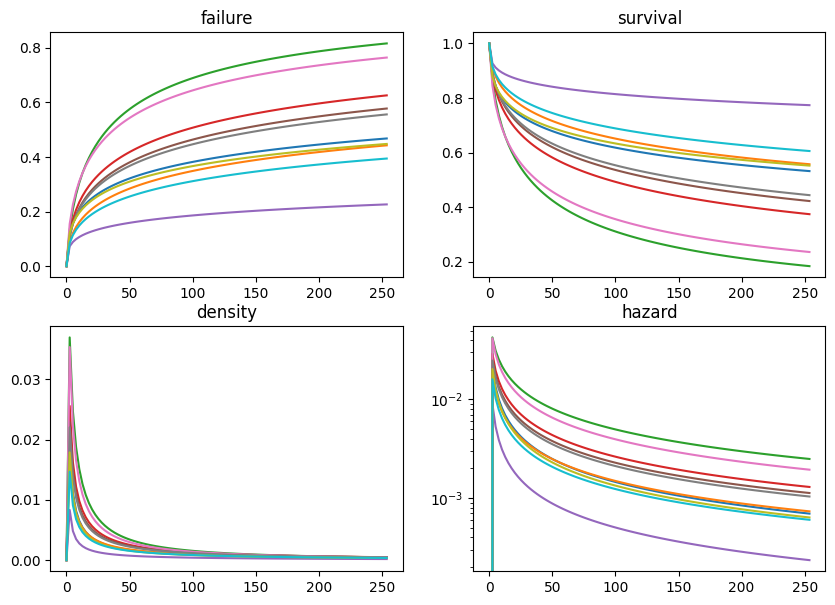

In [9]:
# (max_time limits the x-axis, here we use the 95th percentile of observed times)
m.plot(X_test[:10], max_time=float(np.quantile(y_test["time"], 0.95)))


### Predict survival quantities at specific times

Use `predict(mode, X, times=...)` where `mode` can be:
- `"survival"`: \(S(t)\)
- `"failure"`: \(F(t)\)
- `"density"`: \(f(t)\)
- `"hazard"`: \(h(t)\)

Some modes don't require `times`, e.g. `"expected_time"` and `"risk"` (when supported by the survival module).


In [10]:
# Choose a few time points (here: quantiles of the test-set times)
times = np.quantile(y_test["time"], np.linspace(0.1, 0.9, 5)).astype(np.float32)

# Predict survival for 3 individuals at those time points
preds = m.predict("survival", X_test[:3], times=times)
preds


array([[0.73153746, 0.6571575 , 0.6084246 , 0.57260716, 0.5447117 ],
       [0.7707214 , 0.69308114, 0.64079005, 0.6018071 , 0.5711844 ],
       [0.5375858 , 0.38209352, 0.29459092, 0.23856811, 0.19990286]],
      dtype=float32)

The output is an array with shape `(n_samples, n_times)`.  
Plotting the transposed matrix gives one curve per individual.


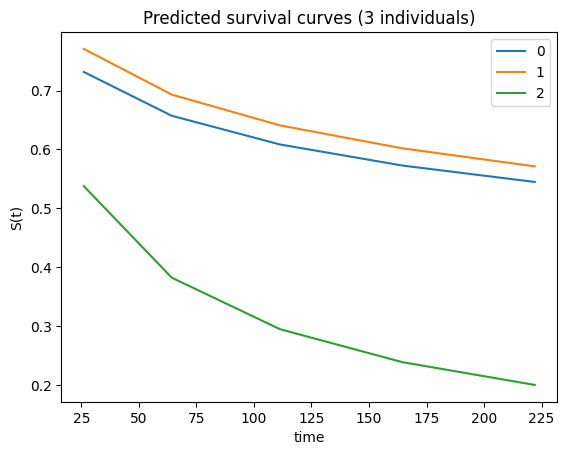

In [11]:
import matplotlib.pyplot as plt

pd.DataFrame(preds.T, index=times).plot()
plt.xlabel("time")
plt.ylabel("S(t)")
plt.title("Predicted survival curves (3 individuals)")
plt.show()


## A simple evaluation: concordance index

The **concordance index (c-index)** measures how well a model ranks individuals by risk:
if person A is predicted riskier than person B, do we usually observe A experiencing the event earlier than B?

For censored data, we can only compare pairs that are *comparable* (scikit-survival handles this).

We'll compute Harrell's c-index using `sksurv`. If it's not installed, you can skip this section.


In [12]:
try:
    from sksurv.metrics import concordance_index_censored

    # A single-time risk score derived from the predicted failure probability at a fixed horizon
    horizon = float(np.quantile(y_train["time"], 0.5))  # median follow-up/event time
    risk_train = m.predict("failure", X_train, times=[horizon])[:, 0]
    risk_test = m.predict("failure", X_test, times=[horizon])[:, 0]

    ci_train = concordance_index_censored(y_train["event"], y_train["time"], risk_train)[0]
    ci_test = concordance_index_censored(y_test["event"], y_test["time"], risk_test)[0]

    print(f"Horizon time: {horizon:.3f}")
    print(f"Train c-index: {ci_train:.3f}")
    print(f"Test  c-index: {ci_test:.3f}")
except ModuleNotFoundError:
    print("sksurv is not installed. Install scikit-survival to compute the c-index.")


Horizon time: 117.567
Train c-index: 0.649
Test  c-index: 0.648


## Selecting survival model and loss

One of the main ideas of `SurvCraft` is that **models are composable**: you can swap the survival distribution, the neural network that predicts its parameters, and the training loss.

Below are a few common choices and when you might use them.


### The 3 building blocks

A `SurvivalPredictor` is made of:

1) **Input module** (`input=...`)  
A neural network mapping features \(X\) → raw distribution parameters.  
Default: a feed-forward network (`FeedForwardNetAdapter`), but you can plug in your own architecture.

2) **Survival module** (`survival=...`)  
A distributional assumption. Examples:
- `ExponentialSurvivalAdapter`: simplest (constant hazard)
- `WeibullSurvivalAdapter`: flexible hazard (increasing/decreasing)
- `LogNormalSurvivalAdapter`: flexible, often right-skewed times
- `StepExpSurvivalAdapter`: piecewise-constant density (non-parametric-ish baseline)

You can also build **derived** models, e.g.:
- `ProportionalHazardSurvivalAdapter(baseline=...)` (PH / “Cox-like” structure)
- `AcceleratedFailureTimeSurvivalAdapter(baseline=...)` (AFT structure)
- `MixtureSurvivalAdapter([...])` mixtures of multiple components

3) **Loss** (`loss=...`)  
How we train with censoring. Two useful defaults:
- `BrierLoss()` — calibration-friendly classification-style loss across times
- `PartialLikelihoodLoss()` — partial-likelihood-style loss (ranking-oriented)


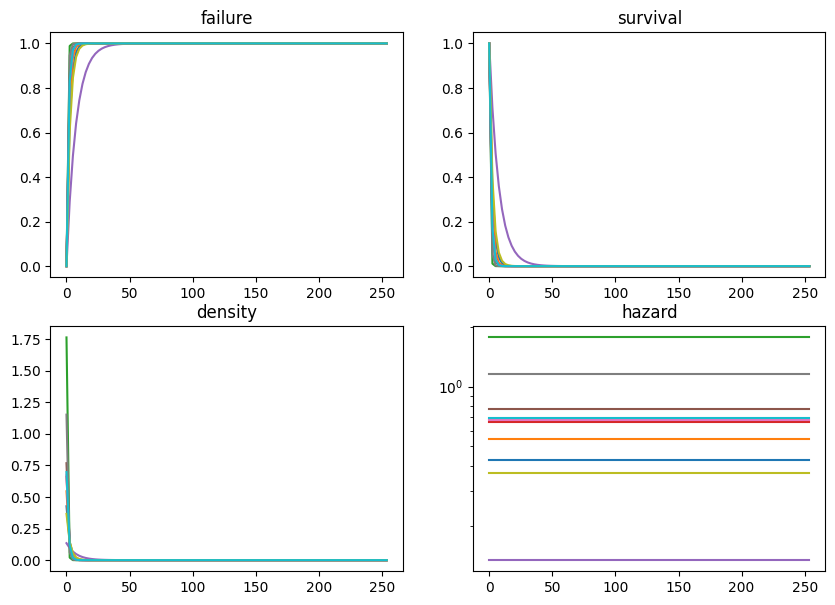

In [ ]:
# Exponential + partial likelihood loss (often a strong baseline for ranking)
m_exp = SurvivalPredictor(
    input=FeedForwardNetAdapter(hidden_sizes=[16]),
    survival=ExponentialSurvivalAdapter(),
    loss=PartialLikelihoodLoss(),
    epochs=20,
    batch_size=128,
    learning_rate=5e-3,
    device=selected_device,
    verbose=0,
)
m_exp.fit(X_train, y_train)
m_exp.plot(X_test[:10], max_time=float(np.quantile(y_test["time"], 0.95)))


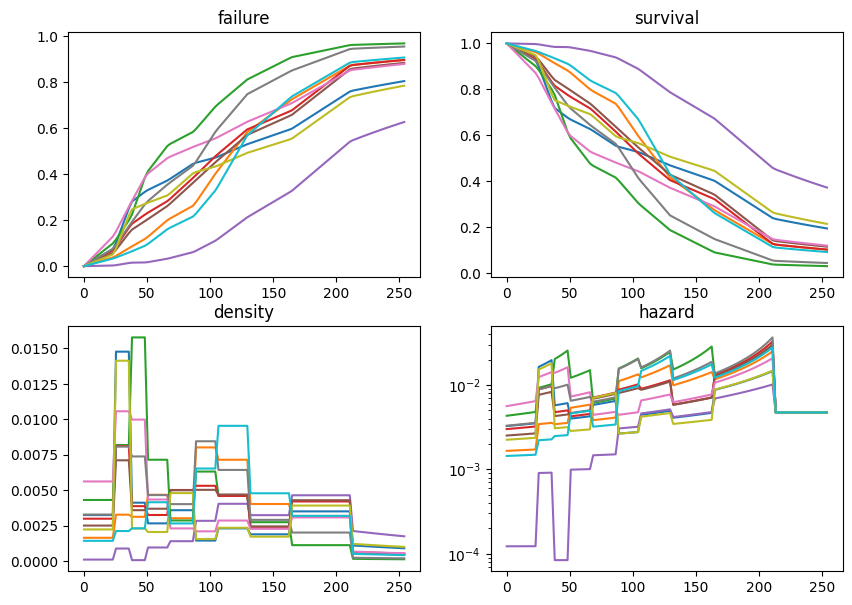

In [15]:
# StepExp + Brier loss (flexible shape; good default when you don't want strong parametric assumptions)
m_step = SurvivalPredictor(
    input=FeedForwardNetAdapter(hidden_sizes=[32, 16], dropout=0.1),
    survival=StepExpSurvivalAdapter(breaks=10),
    loss=BrierLoss(),
    epochs=25,
    batch_size=128,
    learning_rate=5e-3,
    device=selected_device,
    verbose=0,
)
m_step.fit(X_train, y_train)
m_step.plot(X_test[:10], max_time=float(np.quantile(y_test["time"], 0.95)))


### Notes on a few survival modules

- **Exponential**: 1 parameter, constant hazard. Great as a baseline.
- **Weibull**: 2 parameters, hazard can increase or decrease over time.
- **StepExp**: a *step-wise* density / failure curve. It can approximate many shapes without assuming a specific parametric form.
  By default `StepExpSurvivalAdapter(breaks=10)` chooses breaks based on event-time quantiles in the training data (so each interval tends to have a similar number of events).

Derived / compositional modules:
- **Proportional hazards (PH)**: `ProportionalHazardSurvivalAdapter(StepExpSurvivalAdapter(...))`  
  Similar spirit to Cox models: features act as a multiplicative effect on a baseline.
- **Accelerated failure time (AFT)**: `AcceleratedFailureTimeSurvivalAdapter(...)`  
  Features “stretch” or “shrink” the time axis.
- **Mixtures**: `MixtureSurvivalAdapter([ ... ])`  
  Useful when you suspect sub-populations with different risk patterns.


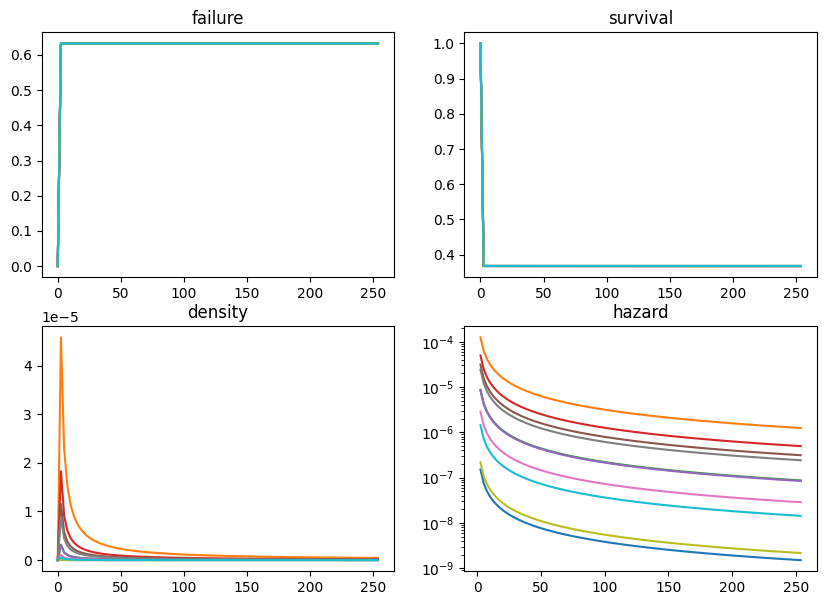

In [16]:
# Weibull + Brier loss (simple parametric, but more flexible than Exponential)
m_weib = SurvivalPredictor(
    input=FeedForwardNetAdapter(hidden_sizes=[32, 16], dropout=0.1),
    survival=WeibullSurvivalAdapter(),
    loss=BrierLoss(),
    epochs=25,
    batch_size=128,
    learning_rate=5e-3,
    device=selected_device,
    verbose=0,
)
m_weib.fit(X_train, y_train)
m_weib.plot(X_test[:10], max_time=float(np.quantile(y_test["time"], 0.95)))


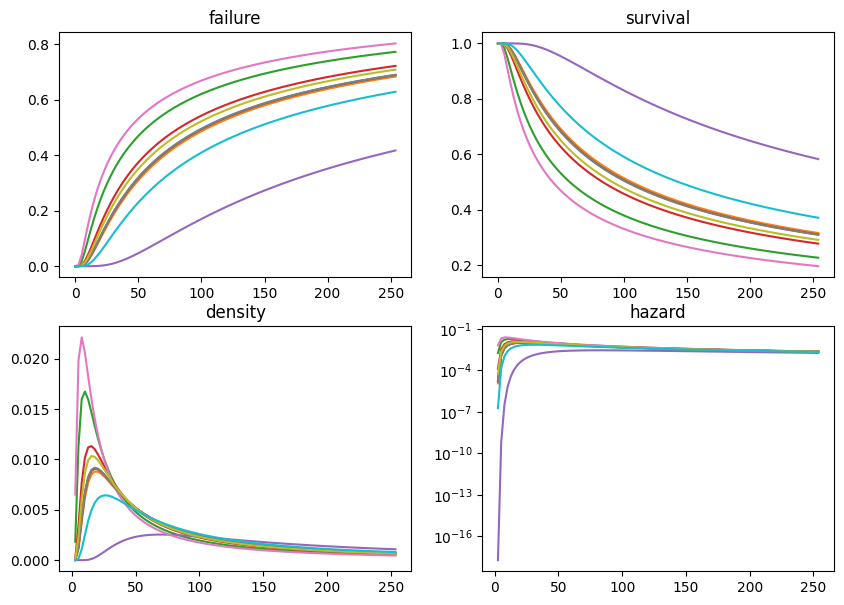

In [17]:
# (Optional) Inverse Gaussian — a first-passage-time distribution (can be useful in diffusion-like settings)
m_ig = SurvivalPredictor(
    input=FeedForwardNetAdapter(hidden_sizes=[32, 16], dropout=0.1),
    survival=InverseGaussianSurvivalAdapter(),
    loss=BrierLoss(),
    epochs=25,
    batch_size=128,
    learning_rate=5e-3,
    device=selected_device,
    verbose=0,
)
m_ig.fit(X_train, y_train)
m_ig.plot(X_test[:10], max_time=float(np.quantile(y_test["time"], 0.95)))


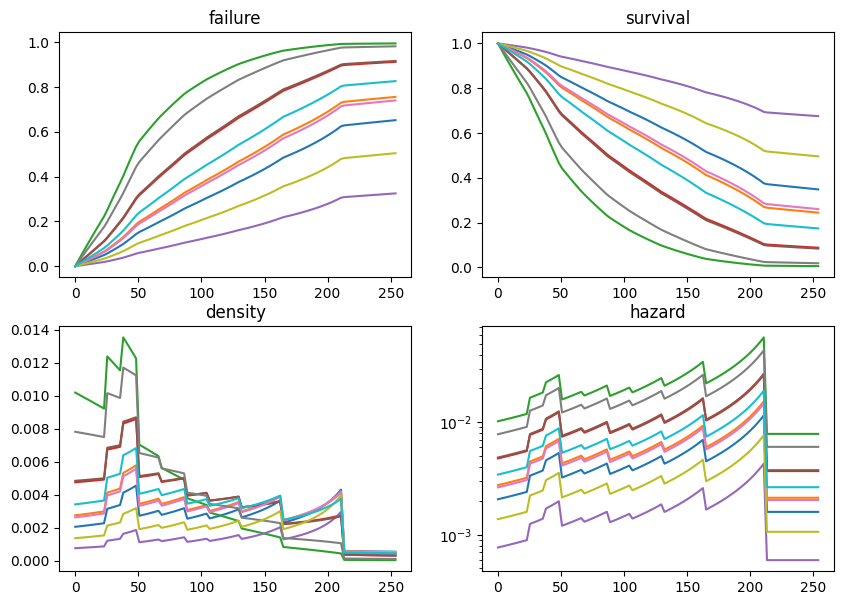

In [19]:
# Proportional hazards model with a StepExp baseline
m_ph = SurvivalPredictor(
    input=FeedForwardNetAdapter(hidden_sizes=[32, 16], dropout=0.1),
    survival=ProportionalHazardSurvivalAdapter(StepExpSurvivalAdapter(breaks=10)),
    loss=PartialLikelihoodLoss(),
    epochs=25,
    batch_size=128,
    learning_rate=5e-3,
    device=selected_device,
    verbose=0,
)
m_ph.fit(X_train, y_train)
m_ph.plot(X_test[:10], max_time=float(np.quantile(y_test["time"], 0.95)))


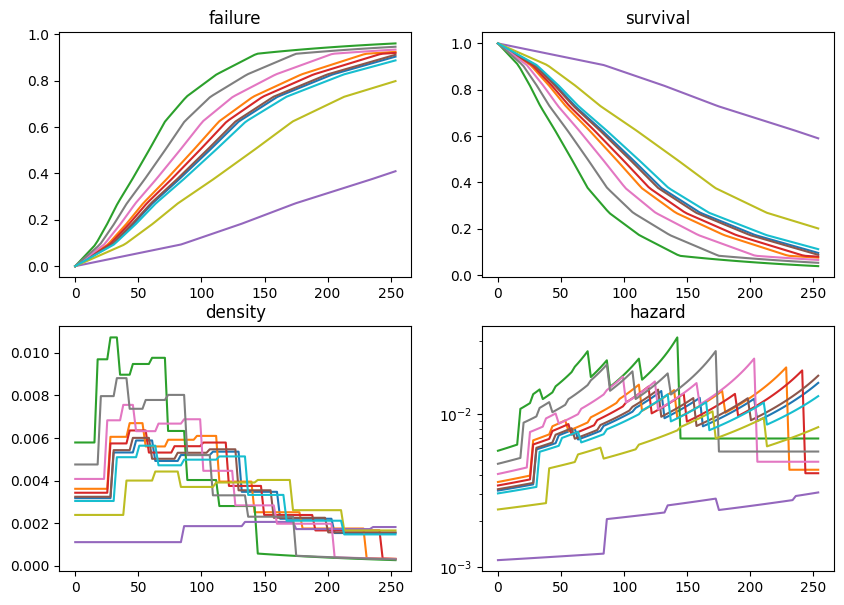

In [20]:
# Accelerated failure time model with a StepExp baseline
m_aft = SurvivalPredictor(
    input=FeedForwardNetAdapter(hidden_sizes=[32, 16], dropout=0.1),
    survival=AcceleratedFailureTimeSurvivalAdapter(StepExpSurvivalAdapter(breaks=10)),
    loss=BrierLoss(),
    epochs=25,
    batch_size=128,
    learning_rate=5e-3,
    device=selected_device,
    verbose=0,
)
m_aft.fit(X_train, y_train)
m_aft.plot(X_test[:10], max_time=float(np.quantile(y_test["time"], 0.95)))


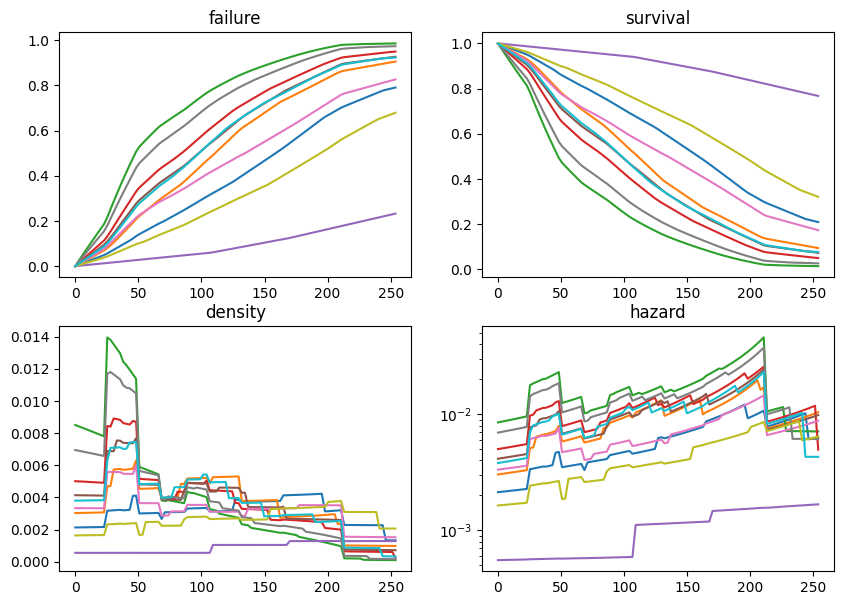

In [21]:
# Mixture model: combine two components (PH and AFT with StepExp baselines)
m_mix = SurvivalPredictor(
    input=FeedForwardNetAdapter(hidden_sizes=[32, 16], dropout=0.1),
    survival=MixtureSurvivalAdapter(
        [
            ProportionalHazardSurvivalAdapter(StepExpSurvivalAdapter(breaks=10)),
            AcceleratedFailureTimeSurvivalAdapter(StepExpSurvivalAdapter(breaks=10)),
        ]
    ),
    loss=BrierLoss(),
    epochs=20,
    batch_size=128,
    learning_rate=1e-2,
    device=selected_device,
    verbose=0,
)
m_mix.fit(X_train, y_train)
m_mix.plot(X_test[:10], max_time=float(np.quantile(y_test["time"], 0.95)))
